In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import json

import matplotlib.pyplot as plt
import mplhep as hep
from matplotlib import colors

import argparse
import os
import uproot
import awkward as ak

from boostedhh import utils

In [2]:
import xgboost as xgb

In [ ]:
os.listdir("/eos/uscms/store/user/lumori/bbtautau/trained_models") #/eos/uscms/store/user/lumori/bbtautau/trained_models

['10July25_baseline',
 '10July25_leptons',
 '13July25_leptons_noXbb',
 '20aug25_loweta_lowreg',
 '20aug25_loweta_lowreg_vbf',
 '28May25_baseline',
 '29July25_loweta_lowreg',
 'test',
 'test_2022']

In [4]:
MODEL_ROOT = Path("/eos/uscms/store/user/lumori/bbtautau/trained_models")
EXP_NAME = "10July25_baseline"
RUN_DIR    = (MODEL_ROOT / EXP_NAME).resolve()

assert RUN_DIR.exists(), f"Run dir not found: {RUN_DIR}"
print("RUN_DIR:", RUN_DIR)
print("FILES:", sorted([p.name for p in RUN_DIR.iterdir()]))

bst = xgb.Booster()
bst.load_model(str(RUN_DIR / "10July25_baseline.json"))

feat_names = getattr(bst, "feature_names", None)
print("Feature names:", feat_names)

RUN_DIR: /eos/uscms/store/user/lmori/bbtautau/trained_models/10July25_baseline
FILES: ['10July25_baseline.json', 'dtrain.buffer', 'dtrain_rescaled.buffer', 'dval.buffer', 'dval_rescaled.buffer', 'evals_result.json', 'feature_importance_gain.pdf', 'feature_importance_gain.png', 'feature_importance_total_gain.pdf', 'feature_importance_total_gain.png', 'feature_importance_weight.pdf', 'feature_importance_weight.png', 'outputs', 'rocs', 'scores', 'training_history.pdf', 'training_history.png', 'weight_stats.csv']
Feature names: ['METPt', 'METPhi', 'ttFatJetPt', 'ttFatJetPhi', 'ttFatJetEta', 'ttFatJetParTmassResApplied', 'ttFatJetParTmassVisApplied', 'ttFatJetParTQCD', 'ttFatJetParTTop', 'ttFatJetParTQCD0HF', 'ttFatJetParTQCD1HF', 'ttFatJetParTQCD2HF', 'ttFatJetParTTopW', 'ttFatJetParTTopbW', 'ttFatJetParTXtauhtauh', 'ttFatJetParTXtauhtaue', 'ttFatJetParTXtauhtaum', 'ttFatJetParTXbb']


In [ ]:
os.listdir("/eos/uscms/store/user/lumori/bbtautau/skimmer/")

['25Feb14Signal_v12_private_signal',
 '25Feb21Signal_v12_private_signal',
 '25Mar7Signal_v12_private_signal',
 '25Oct8_prescale0p001_v12_private_signal',
 '25Sep23AddVars_v12_private_signal']

In [ ]:
DATA_DIR = "/eos/uscms/store/user/lumori/bbtautau/skimmer/25Oct8_prescale0p001_v12_private_signal"
DATA_DIR_2022 = os.path.join(DATA_DIR, '2022')
# DATA_DIR_2022EE = os.path.join(DATA_DIR, '2022EE')
# DATA_DIR_2023 = os.path.join(DATA_DIR, '2023')
# DATA_DIR_2023BPix = os.path.join(DATA_DIR, '2023BPix')

display(os.listdir(DATA_DIR))
# display(os.listdir(DATA_DIR_2022)[:])
# display(os.listdir(DATA_DIR_2022EE))
# display(os.listdir(DATA_DIR_2023)[:15])
# display(os.listdir(DATA_DIR_2023BPix))

PARQUET_DIR = os.path.join(DATA_DIR_2022,  'GluGlutoHHto2B2Tau_kl-1p00_kt-1p00_c2-0p00',"parquet")
display(os.listdir(PARQUET_DIR)[:10])

['2022', '2022EE', '2023', '2023BPix']

['out_0_batch_0.parquet', 'out_1_batch_0.parquet']

In [7]:
df = pd.read_parquet(PARQUET_DIR)
df.head()

GenHiggsEta           GenHiggsPhi           GenHiggsMass        GenHiggsPt  \
            0         1           0         1            0      1          0   
0   -1.050781 -2.085938    0.851562 -2.375000        125.0  125.0      232.5   
1    1.562500  0.235352    0.261719 -2.820312        125.0  125.0      274.0   
0    0.703125 -0.898438   -2.343750  0.722656        125.0  125.0      307.0   
0    0.527344 -0.531250   -1.312500  1.882812        125.0  125.0      312.0   
1    0.303711  0.724609   -2.695312  0.970703        125.0  125.0      298.0   

         GenHiggsChildren      ... VBFJetrawFactor                \
       1                0   1  ...               0             1   
0  260.0               15   5  ...        0.135986 -99999.000000   
1  331.0                5  15  ...        0.061676 -99999.000000   
0  290.0               15   5  ...        0.318359 -99999.000000   
0  322.0               15   5  ...        0.063232 -99999.000000   
1  342.0               15   5  ...        0.060242      0.269287   

  VBFJetbtagPNetB             weight single_weight_genweight  \
                0        1         0                       0   
0            -1.0 -99999.0  0.994185                 0.65807   
1            -1.0 -99999.0  0.170067                 0.65807   
0            -1.0 -99999.0  0.400307                 0.65807   
0            -1.0 -99999.0  0.741031                 0.65807   
1            -1.0     -1.0  0.163990                 0.65807   

  single_weight_pileup single_weight_ISRPartonShower  \
                     0                             0   
0            30.018210                     19.869631   
1             5.134954                     19.869631   
0            12.086789                     19.869631   
0            22.374524                     19.869631   
1             4.951475                     19.869631   

  single_weight_FSRPartonShower weight_noxsec  
                              0             0  
0                     19.869631      0.050035  
1                     19.869631      0.008559  
0                     19.869631      0.020147  
0                     19.869631      0.037295  
1                     19.869631      0.008253  

[5 rows x 403 columns]

In [8]:
jet_indices = sorted({j for (name, j) in df.columns if name == 'ak8FatJetPt'})
jet_indices

[0, 1, 2]

In [9]:
tau_sums = []
for j in jet_indices:
    tau_sum_j = (
        df[('ak8FatJetParTXtauhtauh', j)] +
        df[('ak8FatJetParTXtauhtaue', j)] +
        df[('ak8FatJetParTXtauhtaum', j)]
    )
    tau_sums.append(tau_sum_j)
    
tau_sums = np.column_stack(tau_sums) if len(tau_sums) > 1 else tau_sums[0][:, None]
idx_pos = np.argmax(tau_sums, axis=1)                     # position in jet_indices
chosen_j = np.array([jet_indices[k] for k in idx_pos])    # actual jet index per event

In [10]:
def gather(df, base, chosen_j, dtype=np.float32):
    N = len(df)
    out = np.zeros(N, dtype=dtype)
    for i in range(N):
        key = (base, int(chosen_j[i]))
        out[i] = df[key].iloc[i] if key in df.columns else 0.0
    return out

METPt  = df[('METPt', 0)].to_numpy(np.float32, copy=False)
METPhi = df[('METPhi', 0)].to_numpy(np.float32, copy=False)

ttFatJetPt  = gather(df, 'ak8FatJetPt', chosen_j)
ttFatJetPt  = gather(df, 'ak8FatJetPt', chosen_j)
ttFatJetPhi = gather(df, 'ak8FatJetPhi', chosen_j)
ttFatJetEta = gather(df, 'ak8FatJetEta', chosen_j)

# ParT masses
tt_mRes = gather(df, 'ak8FatJetParTmassResApplied', chosen_j)
tt_mVis = gather(df, 'ak8FatJetParTmassVisApplied', chosen_j)

# QCD / Top components
qcd0  = gather(df, 'ak8FatJetParTQCD0HF', chosen_j)
qcd1  = gather(df, 'ak8FatJetParTQCD1HF', chosen_j)
qcd2  = gather(df, 'ak8FatJetParTQCD2HF', chosen_j)
topW  = gather(df, 'ak8FatJetParTTopW', chosen_j)
topbW = gather(df, 'ak8FatJetParTTopbW', chosen_j)

# Sums required by the model
tt_qcd = (qcd0 + qcd1 + qcd2).astype(np.float32)
tt_top = (topW + topbW).astype(np.float32)

# ττ and Xbb ParT outputs
tx_hh  = gather(df, 'ak8FatJetParTXtauhtauh', chosen_j)
tx_he  = gather(df, 'ak8FatJetParTXtauhtaue', chosen_j)
tx_hm  = gather(df, 'ak8FatJetParTXtauhtaum', chosen_j)
tx_xbb = gather(df, 'ak8FatJetParTXbb', chosen_j)

df_bdt = pd.DataFrame({
    'METPt': METPt,
    'METPhi': METPhi,
    'ttFatJetPt': ttFatJetPt,
    'ttFatJetPhi': ttFatJetPhi,
    'ttFatJetEta': ttFatJetEta,
    'ttFatJetParTmassResApplied': tt_mRes,
    'ttFatJetParTmassVisApplied': tt_mVis,
    'ttFatJetParTQCD': tt_qcd,
    'ttFatJetParTTop': tt_top,
    'ttFatJetParTQCD0HF': qcd0,
    'ttFatJetParTQCD1HF': qcd1,
    'ttFatJetParTQCD2HF': qcd2,
    'ttFatJetParTTopW': topW,
    'ttFatJetParTTopbW': topbW,
    'ttFatJetParTXtauhtauh': tx_hh,
    'ttFatJetParTXtauhtaue': tx_he,
    'ttFatJetParTXtauhtaum': tx_hm,
    'ttFatJetParTXbb': tx_xbb,
}, columns=feat_names).astype(np.float32)

print("df_bdt.shape:", df_bdt.shape)

yhat = bst.inplace_predict(df_bdt)
print(yhat.shape)

# yhat is (nEvents, nClasses)
n_classes = yhat.shape[1]

for cls_idx in range(n_classes):
    df[("bdt_score", cls_idx)] = yhat[:, cls_idx].astype(np.float32)

df[("bdt_best_score", 0)] = np.max(yhat, axis=1).astype(np.float32)
df[("bdt_best_class", 0)] = np.argmax(yhat, axis=1).astype(np.int32)


df_bdt.shape: (120, 18)
(120, 8)


Predicted  0   1  2   4
True                   
GenTauhe   7  10  2  17
GenTauhh   1  21  1  16
GenTauhm   2   2  8  12


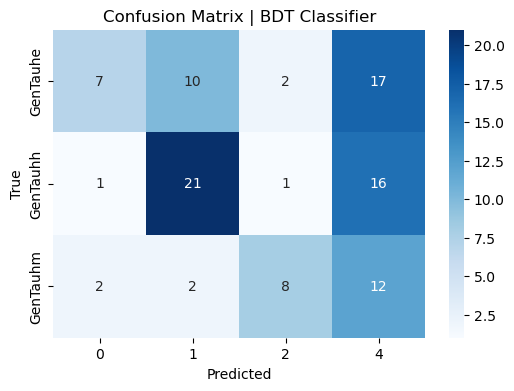

In [11]:
import pandas as pd
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

Signal_Reg = ["GenTauhh", "GenTauhm", "GenTauhe"]

# Build a mapping from GenTauX flag to true label
true_labels = []
pred_labels = []

for sig in Signal_Reg:
    mask = df[(sig, 0)] == True
    filtered_values = df.loc[mask, ("bdt_best_class", 0)]
    
    true_labels.extend([sig] * len(filtered_values))
    pred_labels.extend(filtered_values.values)

# Create a labeled DataFrame
conf_df = pd.DataFrame({"True": true_labels, "Pred": pred_labels})

# Compute confusion matrix
cm = pd.crosstab(conf_df["True"], conf_df["Pred"], rownames=["True"], colnames=["Predicted"], normalize=False)
print(cm)


plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix | BDT Classifier")
plt.show()

In [12]:
# import json

# records = []

# for i in range(len(df)):
#     run  = int(df[('run', 0)].iloc[i])
#     lumi = int(df[('luminosityBlock', 0)].iloc[i])
#     evt  = int(df[('event', 0)].iloc[i])

#     # placeholder: channel SR flags TBD: Ask Ludo
#     # TODO: replace these with the actual final SR cuts you all agreed on,
#     # e.g. tauhh_SR = (channel=="tauhh" AND bdt > WP_tauhh AND ...).
#     tauhh_flag = bool(df[('GenTauhh', 0)].iloc[i])  # temporary proxy
#     tauhmu_flag = bool(df[('GenTauhm', 0)].iloc[i]) # temporary proxy
#     tauhe_flag  = bool(df[('GenTauhe', 0)].iloc[i]) # temporary proxy

#     # build dict of per-class BDT scores
#     # this_scores = {f"class{c}": float(yhat[i, c]) for c in range(yhat.shape[1])}

#     rec = {
#         "run": run,
#         "lumi": lumi,
#         "event": evt,
#         "year": "2022",
#         "channel_flags": {
#             "tauhh": tauhh_flag,
#             "tauhmu": tauhmu_flag,
#             "tauhe": tauhe_flag,
#         },
#         "bdt_scores": this_scores,
#         "jet_pt": float(ttFatJetPt[i]),
#         "jet_eta": float(ttFatJetEta[i]),
#         "met_pt": float(METPt[i]),
#         "weight": float(df[('weight', 0)].iloc[i]),
#     }

#     records.append(rec)

# # write to disk
# out_json_path = "overlap_payload_2022.json"
# with open(out_json_path, "w") as f:
#     for r in records:
#         f.write(json.dumps(r) + "\n")

# print("wrote", out_json_path, "with", len(records), "events")


In [13]:
# import json

# records = []

# # SR_chan_flag = "GenTauhh"
# # SR_chan_flag = "GenTauhm"
# SR_chan_flag = "GenTauhe"

# for i in range(len(df)):
#     if bool(df[(SR_chan_flag, 0)].iloc[i]):
#         run  = int(df[('run', 0)].iloc[i])
#         lumi = int(df[('luminosityBlock', 0)].iloc[i])
#         evt  = int(df[('event', 0)].iloc[i])

#         rec = {
#             "run": run,
#             "luminosityBlock": lumi,
#             "event": evt,
#             "year": "2022",
#         }

#         records.append(rec)

# # write to disk
# out_json_path = f"{SR_chan_flag}.json"
# with open(out_json_path, "w") as f:
#     for r in records:
#         f.write(json.dumps(r) + "\n")

# print("wrote", out_json_path, "with", len(records), "events")


In [14]:
df[("ak8FatJetParTXbbvsQCDTop")]

,0,1,2
0,0.000019,-99999.000000,-99999.0
1,0.039837,0.000074,-99999.0
0,0.000002,0.119943,-99999.0
0,0.728064,-99999.000000,-99999.0
1,0.733661,-99999.000000,-99999.0
...,...,...,...
2,0.940131,-99999.000000,-99999.0
3,0.000632,0.001388,-99999.0
4,0.036664,0.000065,-99999.0
5,0.045761,-99999.000000,-99999.0


In [ ]:
def compute_sig_bkg_abcd(self, years, txbbcut, txttcut, mbb1, mbb2, mtt1, mtt2):
    # pass/fail from taggers
    sig_pass = 0  # resonant region pass, signal
    bg_pass_sb = 0  # sideband region pass, data
    bg_fail_res = 0  # resonant region fail, data
    bg_fail_sb = 0  # sideband region fail, data
    for year in years:
        # A
        cut_sig_pass = (
            (self.txbbs[year][self.sig_key_channel] > txbbcut)
            & (self.txtts[year][self.sig_key_channel] > txttcut)
            & (self.massbb[year][self.sig_key_channel] > mbb1)
            & (self.massbb[year][self.sig_key_channel] < mbb2)
            & (self.ptbb[year][self.sig_key_channel] > 250)
            & (self.pttt[year][self.sig_key_channel] > 200)
        )

        sig_pass += np.sum(
            self.events_dict[year][self.sig_key_channel].get_var("finalWeight")[cut_sig_pass]
        )

        for key in self.channel.data_samples:
            # B
            cut_bg_pass_sb = (
                (self.txbbs[year][key] > txbbcut)
                & (self.txtts[year][key] > txttcut)
                & (self.ptbb[year][key] > 250)
                & (self.pttt[year][key] > 200)
            )

            msb1 = (self.massbb[year][key] > SHAPE_VAR["range"][0]) & (
                self.massbb[year][key] < mbb1
            )
            msb2 = (self.massbb[year][key] > mbb2) & (
                self.massbb[year][key] < SHAPE_VAR["range"][1]
            )
            bg_pass_sb += np.sum(
                self.events_dict[year][key].get_var("finalWeight")[cut_bg_pass_sb & msb1]
            )
            bg_pass_sb += np.sum(
                self.events_dict[year][key].get_var("finalWeight")[cut_bg_pass_sb & msb2]
            )
            
            # C
            cut_bg_fail_sb = (
                ((self.txbbs[year][key] < txbbcut) | (self.txtts[year][key] < txttcut))
                & (self.ptbb[year][key] > 250)
                & (self.pttt[year][key] > 200)
            )
            bg_fail_sb += np.sum(
                self.events_dict[year][key].get_var("finalWeight")[cut_bg_fail_sb & msb1]
            )
            bg_fail_sb += np.sum(
                self.events_dict[year][key].get_var("finalWeight")[cut_bg_fail_sb & msb2]
            )
            
            # D
            cut_bg_fail_res = (
                ((self.txbbs[year][key] < txbbcut) | (self.txtts[year][key] < txttcut))
                & (self.massbb[year][key] > mbb1)
                & (self.massbb[year][key] < mbb2)
                & (self.ptbb[year][key] > 250)
                & (self.pttt[year][key] > 200)
            )

            bg_fail_res += np.sum(
                self.events_dict[year][key].get_var("finalWeight")[cut_bg_fail_res]
            )

    del cut_sig_pass, cut_bg_pass_sb, cut_bg_fail_sb, cut_bg_fail_res, msb1, msb2

    # signal=A, B, C, D, TF = C/D
    # C = bg_fail_res?
    # D = bg_fail_sb?
    
    tf = bg_fail_res / bg_fail_sb if bg_fail_sb > 0 else 0